#  Random Forest Regressor — Hotel Price Prediction

Train a Random Forest Regressor with hyperparameter tuning on Indian hotel pricing data.

**Prerequisites**: Run `01_data_exploration.ipynb` first.

---

## 1. Setup

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Preprocessed Data

In [3]:
data = np.load('models/train_test_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# Load feature names saved by notebook 01
feature_names = joblib.load('models/feature_names.pkl')

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')
print(f'Features:         {X_train.shape[1]}')
print(f'Feature names:    {feature_names}')

Training samples: 464
Test samples:     116
Features:         8
Feature names:    ['Rating', 'Reviews', 'Star Rating', 'City', 'Rating Desc', 'Has Landmark', 'Distance km', 'Tax']


## 3. Train Random Forest with Hyperparameter Tuning

In [4]:
# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

print('🔍 Running Grid Search (this may take a few minutes)...')

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=5, scoring='r2',
    verbose=1, n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'✅ Best CV R² Score: {grid_search.best_score_:.4f}')

🔍 Running Grid Search (this may take a few minutes)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
✅ Best CV R² Score: -0.0317


In [5]:
# Use best model
rf_model = grid_search.best_estimator_

# Cross-validation scores
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print(f'Cross-Validation R² Scores: {cv_scores}')
print(f'Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation R² Scores: [-0.51085939  0.43932978  0.11410912  0.03034912 -0.2316179 ]
Mean CV R²: -0.0317 ± 0.3214


## 4. Evaluate Model

In [6]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

train_metrics = {
    'MAE': mean_absolute_error(y_train, y_train_pred),
    'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
    'R² Score': r2_score(y_train, y_train_pred)
}

test_metrics = {
    'MAE': mean_absolute_error(y_test, y_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
    'R² Score': r2_score(y_test, y_test_pred)
}

print('📊 Training Metrics:')
for k, v in train_metrics.items():
    print(f'   {k}: {v:.4f}')

print('\n📊 Test Metrics:')
for k, v in test_metrics.items():
    print(f'   {k}: {v:.4f}')

📊 Training Metrics:
   MAE: 1027.6495
   RMSE: 4413.1001
   R² Score: 0.5912

📊 Test Metrics:
   MAE: 1292.7327
   RMSE: 2513.8968
   R² Score: 0.3609


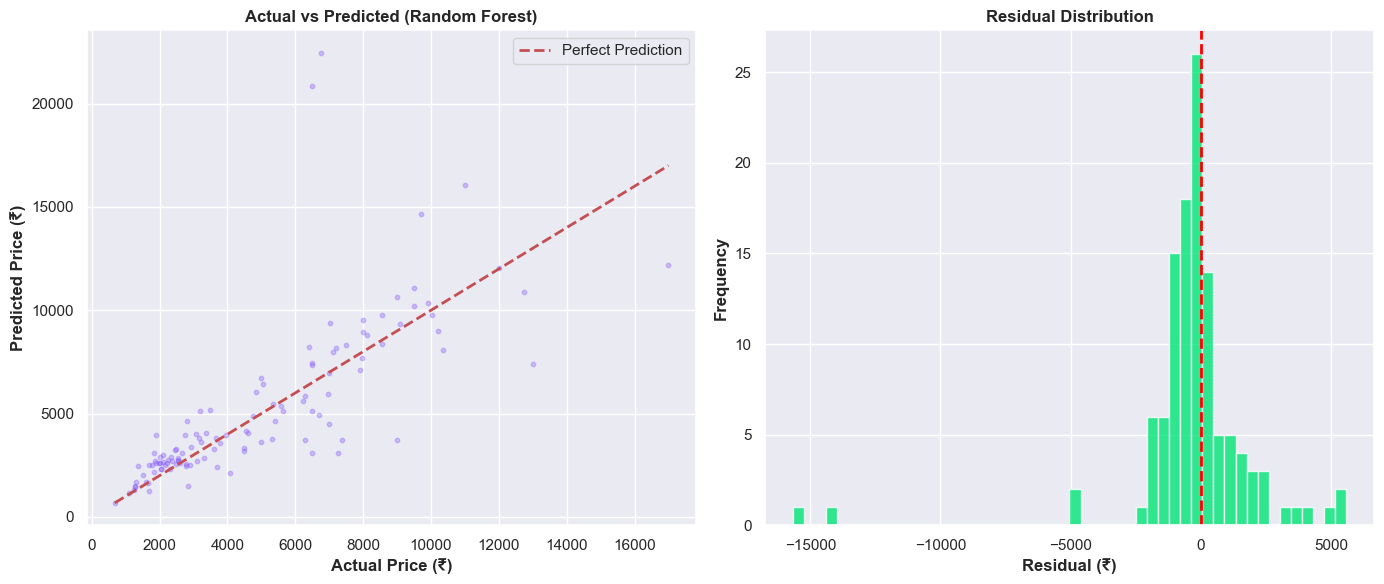

In [7]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_test_pred, alpha=0.3, c='#7c4dff', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (₹)', fontweight='bold')
axes[0].set_ylabel('Predicted Price (₹)', fontweight='bold')
axes[0].set_title('Actual vs Predicted (Random Forest)', fontweight='bold')
axes[0].legend()

residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=50, color='#00e676', alpha=0.8, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (₹)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

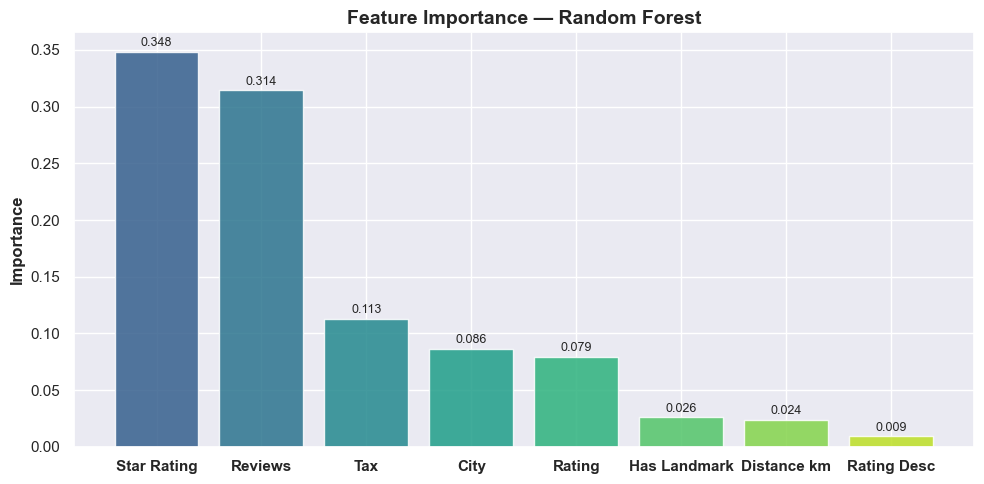

In [8]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_names)))
ax.bar(range(len(feature_names)), importances[indices], color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices], fontweight='bold')
ax.set_ylabel('Importance', fontweight='bold')
ax.set_title('Feature Importance — Random Forest', fontweight='bold', fontsize=14)

for i, (idx, imp) in enumerate(zip(indices, importances[indices])):
    ax.text(i, imp + 0.005, f'{imp:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Save Model

In [9]:
os.makedirs('models', exist_ok=True)
model_path = 'models/random_forest.pkl'
joblib.dump(rf_model, model_path)

print(f'✅ Model saved to: {model_path}')
print(f'   File size: {os.path.getsize(model_path) / 1024:.1f} KB')
print(f'   Best params: {grid_search.best_params_}')
print(f'\n📊 Final Test R² Score: {test_metrics["R² Score"]:.4f}')

✅ Model saved to: models/random_forest.pkl
   File size: 3000.8 KB
   Best params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

📊 Final Test R² Score: 0.3609


In [10]:
print('\n🎉 Random Forest Training Complete!')
print('\nNext: Run 04_gradient_boosting.ipynb')


🎉 Random Forest Training Complete!

Next: Run 04_gradient_boosting.ipynb
